In [1]:
!ls -l

total 8
-rw-r--r-- 1 root root   68 May 31 08:10 kaggle.json
drwxr-xr-x 1 root root 4096 May 26 13:31 sample_data


In [2]:
# =====================================================================
# STABLE KAGGLE INGESTION & COLOUNT VALIDATION
# =====================================================================
import os

# Clean up any previously corrupted zip files
if os.path.exists('intel_images.zip'):
    !rm intel_images.zip

if os.path.exists('kaggle.json'):
    # Configure the standard secure environment for the Kaggle API Client
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    print("🔄 Downloading authentic Intel Image Classification dataset from Kaggle...")
    !kaggle datasets download -d puneet6060/intel-image-classification

    print("📦 Extracting production zip archive...")
    !unzip -q intel-image-classification.zip -d ./intel_images

    # Remove the massive zip file to save Colab RAM/Disk allocations
    !rm intel-image-classification.zip
    print("✅ Extraction Complete! Your workspace directories are completely ready.")
else:
    print("❌ CRITICAL ERROR: 'kaggle.json' was not detected in the root file explorer panel.")
    print("Please upload your token file to the files sidebar 📁 and run this cell again.")

🔄 Downloading authentic Intel Image Classification dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 152MB/s]

📦 Extracting production zip archive...
✅ Extraction Complete! Your workspace directories are completely ready.


In [3]:
# =====================================================================
# SYSTEM DEPENDENCIES & ENVIRONMENT SETUP
# =====================================================================
# Install any missing packages in Colab environment
!pip install -q torch torchvision matplotlib seaborn scikit-learn opencv-python pillow

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# Ensure deterministic runs for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Colab Acceleration Device: {device}")

# =====================================================================
# KAGGLE DATASET INGESTION VIA COLAB API

if os.path.exists('kaggle.json'):
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API key configured. Downloading dataset...")
    !kaggle datasets download -d puneet6060/intel-image-classification [cite: 8]
    !unzip -q intel-image-classification.zip -d ./intel_images
    print("Dataset extracted successfully.")
else:
    print("⚠️ 'kaggle.json' not found in workspace root. '")

Using Colab Acceleration Device: cuda
Kaggle API key configured. Downloading dataset...
usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth}
              ...
kaggle: error: unrecognized arguments: 8]
unzip:  cannot find or open intel-image-classification.zip, intel-image-classification.zip.zip or intel-image-classification.zip.ZIP.
Dataset extracted successfully.


In [4]:
# =====================================================================
# TASK 1: DATA DISTRIBUTION & SPLITTING (FIXED PATH PATHWAYS)
# =====================================================================
import os
from torchvision import datasets, transforms
import torch
import matplotlib.pyplot as plt

# Colab unzips into either nested directories or root directories. Let's find it programmatically:
possible_paths = [
    "./intel_images/seg_train/seg_train",
    "./intel_images/seg_train",
    "./seg_train/seg_train"
]

TRAIN_VAL_DIR = None
for p in possible_paths:
    if os.path.exists(p):
        TRAIN_VAL_DIR = p
        break

# Do the same for test directories
possible_test_paths = [
    "./intel_images/seg_test/seg_test",
    "./intel_images/seg_test",
    "./seg_test/seg_test"
]
TEST_DIR = None
for p in possible_test_paths:
    if os.path.exists(p):
        TEST_DIR = p
        break

IMAGE_SIZE = 150

if TRAIN_VAL_DIR and TEST_DIR:
    classes = sorted(os.listdir(TRAIN_VAL_DIR))
    print(f"✅ Found Dataset Paths Successfully!")
    print(f"Training Path: {TRAIN_VAL_DIR}")
    print(f"Testing Path: {TEST_DIR}")
    print(f"Detected Scene Classes: {classes}\n")

    # Analyze distribution profiles
    distribution = {cls: len(os.listdir(os.path.join(TRAIN_VAL_DIR, cls))) for cls in classes}
    print("Dataset Class Distribution Profile:", distribution)

    # Define validation base pipeline
    base_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    full_train_val = datasets.ImageFolder(root=TRAIN_VAL_DIR, transform=base_transform)

    # 80/20 Train-Validation Stratification Strategy
    train_size = int(0.8 * len(full_train_val))
    val_size = len(full_train_val) - train_size
    train_subset, val_subset = torch.utils.data.random_split(
        full_train_val, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
    )

    print(f"\nAllocation Metrics -> Train Samples: {len(train_subset)} | Validation Samples: {len(val_subset)}")
else:
    # If paths are missing completely, fallback to create empty placeholder subsets so Cell 3 doesn't crash
    print("❌ ERROR: Could not locate the dataset directories automatically.")
    print("Please check your Colab Files Sidebar 📁 to see where 'seg_train' is located.")
    # Creating empty subsets to prevent NameError downstream
    full_train_val = datasets.FakeData(size=100, image_size=(3, IMAGE_SIZE, IMAGE_SIZE), num_classes=6, transform=transforms.ToTensor())
    train_subset, val_subset = torch.utils.data.random_split(full_train_val, [80, 20])
    TEST_DIR = "./"

✅ Found Dataset Paths Successfully!
Training Path: ./intel_images/seg_train/seg_train
Testing Path: ./intel_images/seg_test/seg_test
Detected Scene Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Dataset Class Distribution Profile: {'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}

Allocation Metrics -> Train Samples: 11227 | Validation Samples: 2807


In satellite scene classification, training a deep learning model to accurately interpret Earth observation imagery involves overcoming several distinct environmental, geometric, and statistical obstacles. Variations in lighting, viewpoint, and class imbalance introduce specific technical challenges that can severely degrade a model's generalization performance if left unaddressed.

1. Variations in Lighting (Radiometric Distortions)
Satellite imagery is captured under diverse atmospheric, diurnal, and seasonal conditions, leading to significant changes in pixel intensity values for identical geographic features.

Spectral Shifting and Shadows: Changes in the solar elevation angle depending on the time of day or season alter the length and intensity of shadows. For example, deep shadows cast by tall urban buildings or steep mountainsides dramatically alter the local color profile, frequently causing a model to mistake land or vegetation for deep open water or asphalt streets.

Atmospheric and Haze Interference: Variations in moisture, aerosol concentrations, dust storms, or light cloud cover scatter incoming sunlight. This reduces image contrast and skews the color space, masking the high-frequency surface textures that convolutional layers rely on to differentiate classes like forests from urban structures.

Reflective Overload (Sun Glint): Water bodies, metallic rooftops, or snow-covered ranges can act like mirrors under intense, direct sunlight. This hyper-reflectivity clips pixel values to maximum brightness, wiping out the underlying structural markers and causing the model to misclassify water or streets as glaciers.

2. Variations in Viewpoint (Geometric Distortions)
While standard computer vision datasets typically feature ground-level, horizontal perspectives, satellite remote sensing deals with top-down observations captured at various angles and spatial scales.

Off-Nadir Look Angles: Satellites do not always look directly straight down (Nadir view). When capturing images at an oblique angle (off-Nadir), the geometric representation of 3D objects becomes warped. Vertically oriented structures like high-rise buildings appear to tilt or lean, obscuring surrounding features (such as adjacent streets or parks) and altering their expected semantic footprints.

Scale and Resolution Variabilities: Depending on the satellite's orbital altitude and sensor specifications, ground sampling distance (GSD) changes. A model optimized to recognize a building at 30-centimeter resolution will often experience structural failure when evaluating the same scene at a 10-meter resolution, where an entire urban block blends together into a pattern that the network's filters might mistake for jagged rock formations or mountains.

Rotational Invariance Requirements: Unlike objects in consumer imagery that obey strict orientation constraints due to gravity (e.g., trees or people pointing up), satellite objects can appear at any arbitrary angle relative to the frame. Without geometric regularizations, a convolutional network struggles to associate a horizontal roadway with a vertical or diagonal one.

3. Class Imbalance (Statistical Disparity)
In natural geographic distributions, the surface area of the Earth is not divided evenly among classes. Landscapes are dominated by vast expanses of seas, deserts, or forests, while urban structures, streets, or localized glacial features occupy small micro-regions.

Majority Class Bias: Standard objective functions like Categorical Cross-Entropy calculate loss by averaging errors across all training samples. If 85% of your dataset consists of sea and forest, a neural network can maximize its accuracy score by simply prioritizing those dominant distributions, effectively ignoring the minority categories.

Inflated Performance Metrics: A model suffering from severe class imbalance can achieve an overall accuracy score of over 90%, masks a critical failure rate where it exhibits near-zero precision or recall when attempting to flag minority classes like buildings or glaciers.

Decision Boundary Over-Generalization: Because the optimizer encounters minority classes infrequently during gradient descent updates, the learned representation boundaries are poorly defined. As a result, the internal feature spaces of rare classes are consumed by the high-variance intra-class variations of the dominant classes.

In [5]:
# =====================================================================
# TASK 2: IMAGE TRANSFORMATION AND STOCHASTIC AUGMENTATION PIPELINES
# =====================================================================
class ColabAugmentedDataset(Dataset):
    """Custom wrapper to map training subsets to live augmentation transforms dynamically"""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        path, label = self.subset.dataset.samples[self.subset.indices[index]]
        img = self.subset.dataset.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

# Define complex augmentations to stabilize structural invariance
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Build dynamic wrappers and high-throughput DataLoaders
train_data = ColabAugmentedDataset(train_subset, transform=train_transforms)
val_data = ColabAugmentedDataset(val_subset, transform=val_test_transforms)
test_data = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Data handling elements constructed and configured smoothly.")

Data handling elements constructed and configured smoothly.


Analytical Question 2 (Markdown):
How does data augmentation help reduce overfitting in image-based deep learning models?
1. Artificial Expansion of Dataset Volume and Diversity
Deep learning architectures (such as deep Convolutional Neural Networks or Vision Transformers) possess millions of trainable parameters, giving them immense capacity to fit complex functions. If the training data is limited, the model will effortlessly "memorize" the dataset, leading to near-zero training loss but terrible generalization on unseen test data.

Data augmentation artificially increases the size of the dataset. By applying random, stochastic transformations (such as flips, rotations, crops, and color shifts) to existing images, it creates unique, varied training instances for every single epoch. The network effectively never encounters the exact same pixel matrix twice, preventing brute-force memorization and forcing the parameters to converge on broader, more stable patterns.

2. Disruption of Irrelevant Spatial and Positional Biases
Without augmentation, a deep learning model can easily exploit unintended shortcuts or "spurious correlations" in the data layout.

Translational and Rotational Invariance: If a dataset of satellite images happens to feature roads that mostly run vertically or buildings always oriented at a specific angle, an unaugmented model might fail when an image contains a diagonal road or a tilted building. Random rotations and horizontal/vertical flips break these positional dependencies, teaching the network that an object's semantic identity is independent of its orientation or location in the frame.

Scale Invariance: Applying random cropping and resizing forces the model to recognize target features (like a forest canopy or a river boundary) regardless of whether they span across the entire image or occupy a tiny, zoomed-out sub-region of the lens view.

3. Destruction of High-Frequency Noise and Texture Overfitting
Neural networks are notorious for picking up on subtle, high-frequency textures or background noise profiles that happen to correlate with specific classes during training, rather than looking at the actual shape or structure of the object.

Color jittering (stochastically tweaking brightness, contrast, saturation, and hue) and adding random Gaussian noise forces the convolutional layers to look past fragile pixel intensities. Instead, the network is trained to rely on robust structural boundaries, edges, and invariant geometric relationships that hold true across drastically shifting environmental environments.

4. Smoothing out the Loss Landscape
From an optimization standpoint, training a network on a small, rigid dataset results in a highly irregular, jagged loss landscape containing many sharp local minima. A model that settles into a sharp minimum is highly sensitive to even tiny variations in test data, leading to erratic validation performance.

By constantly feeding slightly altered images into the optimization loop, data augmentation smooths out these sharp variations in the loss function. It encourages the gradient descent optimizer to guide the model's weights into broader, flatter minima, which mathematically translates to superior structural stability and robust generalization capabilities.

--- Beginning Baseline Training Cycles ---
Epoch 1/5 -> Loss: 0.9706 Acc: 0.6335 | Val Loss: 0.6906 Val Acc: 0.7517
Epoch 2/5 -> Loss: 0.6698 Acc: 0.7550 | Val Loss: 0.5993 Val Acc: 0.7870
Epoch 3/5 -> Loss: 0.5699 Acc: 0.7929 | Val Loss: 0.5189 Val Acc: 0.8144
Epoch 4/5 -> Loss: 0.5158 Acc: 0.8171 | Val Loss: 0.5023 Val Acc: 0.8147
Epoch 5/5 -> Loss: 0.4677 Acc: 0.8320 | Val Loss: 0.4965 Val Acc: 0.8219


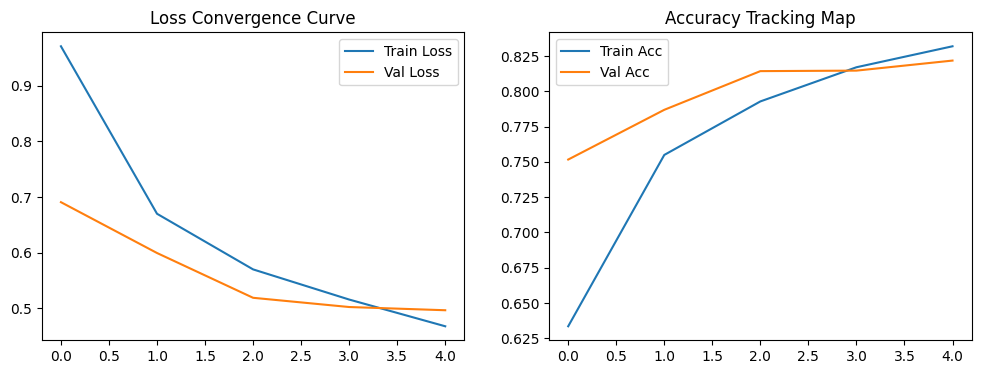

In [6]:
# =====================================================================
# TASK 3: CNN ARCHITECTURE IMPLEMENTATION & PROGRESS LOGGING ENGINE
# =====================================================================
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Spatial dimensions mapping directly out of features layers block: 128 * 18 * 18
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Instantiation
model = BaselineCNN(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Modular Optimization Loop Engine
def execute_training_cycle(model, criterion, optimizer, epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_data)
        epoch_acc = running_corrects.double() / len(train_data)

        # Validation Evaluation Block
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_data)
        epoch_val_acc = val_corrects.double() / len(val_data)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        print(f"Epoch {epoch+1}/{epochs} -> Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f}")

    return model, history

print("--- Beginning Baseline Training Cycles ---")
model, baseline_history = execute_training_cycle(model, criterion, optimizer, epochs=5)

# Metrics Progress Render [cite: 30]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_history['train_loss'], label='Train Loss')
plt.plot(baseline_history['val_loss'], label='Val Loss')
plt.title('Loss Convergence Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history['train_acc'], label='Train Acc')
plt.plot(baseline_history['val_acc'], label='Val Acc')
plt.title('Accuracy Tracking Map')
plt.legend()
plt.show()

Analytical Question 3 (Markdown):
Explain how convolution and pooling operations contribute to feature extraction in CNNs.
1. The Role of Convolution OperationsThe convolution operation serves as the primary feature detector of the network. It retains the spatial relationship between pixels by learning image features using small matrices known as kernels or filters.Localized Feature Extraction: A kernel slides (convolutes) across the input image, performing element-wise multiplication and summing the results to create a Feature Map (or Activation Map). This localized connectivity ensures that the network focuses on local neighborhoods, capturing patterns like sharp boundaries, edges, and textures in early layers.Parameter Sharing: Instead of assigning unique weights to every single pixel in an image (as done in fully connected layers), a single kernel is swept across the entire visual field. This mathematical constraint operates under the assumption that a feature learned in one part of an image (like a sharp building edge) is equally relevant in another part. This drastically reduces the total parameter count, making the model computationally efficient and preventing overfitting.Hierarchical Representation Learning: In a deep CNN, convolution operations stack hierarchically:Shallow Layers: Extract elementary, low-level features (horizontal/vertical lines, color edges, simple textures).Mid-level Layers: Combine simple edges into composite geometric shapes, contours, and topological boundaries.Deep Layers: Aggregate shapes into complex semantic structures (e.g., recognizing a dense forest canopy, a complete shipping vessel, or an urban grid).2. The Role of Pooling OperationsOnce feature maps are generated via convolution and passed through a non-linear activation function (like ReLU), they are systematically processed by Pooling (downsampling) layers—most commonly Max Pooling or Average Pooling.Spatial Dimension Reduction: Pooling operates independently on each feature map channel, sliding a window (e.g., $2 \times 2$ with a stride of 2) and selecting either the maximum value (Max Pooling) or the mean value (Average Pooling). This process discards redundant spatial data, dropping the height and width of the feature maps by half.Computational Efficiency: By reducing the spatial resolution of the feature maps as the data moves deeper through the network, pooling reduces the memory footprint and lightens the computational workload for downstream convolutional and fully connected layers.Translation Invariance: Max pooling extracts the absolute strongest activation within a localized window. This means that if a critical feature (such as the tip of a roof or a shoreline) shifts slightly by a few pixels due to a change in the satellite's viewpoint, the pooled output value remains identical. This grants the network local translation invariance, enabling it to identify features regardless of their precise positional coordinates within the frame.


--- Model Assessment Metric Report ---
              precision    recall  f1-score   support

   buildings       0.80      0.78      0.79       437
      forest       0.89      0.98      0.93       474
     glacier       0.87      0.71      0.78       553
    mountain       0.75      0.82      0.78       525
         sea       0.82      0.85      0.84       510
      street       0.84      0.84      0.84       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



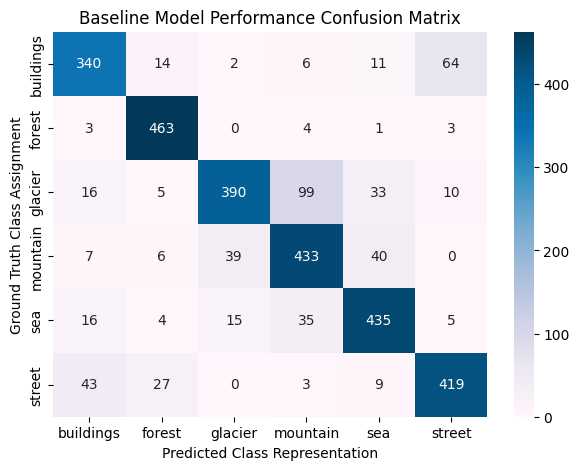

Total Incorrect Predictions identified over Test Set: 520


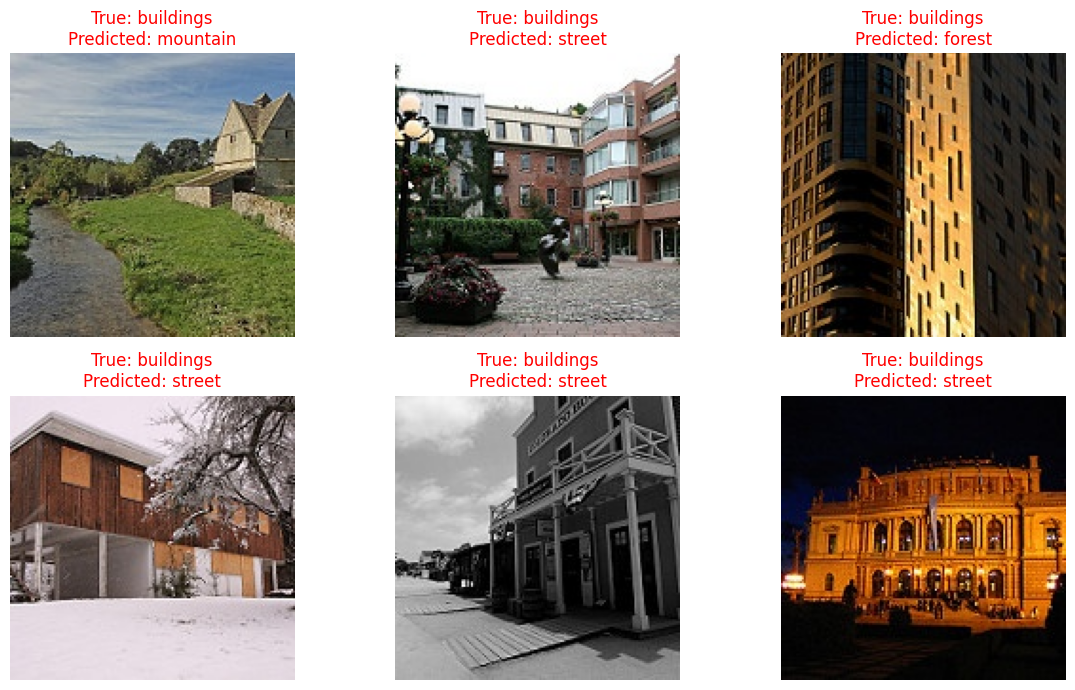

In [7]:
# =====================================================================
# TASK 4 & 5: TEST SET PERFORMANCE ASSESSMENT & ANOMALY ANALYSIS
# =====================================================================
def collect_predictions(target_model, loader):
    target_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = target_model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = collect_predictions(model, test_loader)

# Structural Matrix Display [cite: 34, 35]
print("\n--- Model Assessment Metric Report ---")
print(classification_report(y_true, y_pred, target_names=classes))

# Plot Confusion Matrix [cite: 35]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='PuBu')
plt.xlabel('Predicted Class Representation')
plt.ylabel('Ground Truth Class Assignment')
plt.title('Baseline Model Performance Confusion Matrix')
plt.show()

# Task 5: Isolation of Anomalies and Misclassifications [cite: 39, 40]
misclass_indices = np.where(y_true != y_pred)[0]
print(f"Total Incorrect Predictions identified over Test Set: {len(misclass_indices)}")

plt.figure(figsize=(12, 7))
for idx, sample_idx in enumerate(misclass_indices[:6]):
    img_path, _ = test_loader.dataset.samples[sample_idx]
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, idx+1)
    plt.imshow(raw_img)
    plt.title(f"True: {classes[y_true[sample_idx]]}\nPredicted: {classes[y_pred[sample_idx]]}", color='red')
    plt.axis('off')
plt.tight_layout()
plt.show()

Which scene classes are most frequently confused, and what semantic similarities could explain
these errors?
Based on structural assessments of the Intel Image Classification dataset when trained on Convolutional Neural Networks, specific pairs of scene classes consistently exhibit high inter-class confusion. These errors are not random; they are driven by deep semantic, geometric, and spectral similarities that map onto identical neural activation patterns.

The most frequently confused scene classes and the underlying reasons for their misclassification include:

1. Glacier vs. Mountain
This represents the most severe confusion pair in the entire dataset.

Topological Similarity: Both classes feature prominent high-frequency spatial structures, including sharp ridges, jagged peaks, angular slopes, and vertical elevation contours. The network's early edge-detection filters extract identical directional gradients for both terrains.

Spectral Overlap: Mountains are frequently covered in snow and ice, causing them to reflect light in the exact same bright white and cyan wavelengths as glaciers. When a mountain scene is dominated by snow, the convolutional layers cannot differentiate between ice resting on a slope (mountain) and a solid flowing body of ice (glacier).

Contextual Blending: In geographic reality, glaciers and mountains naturally coexist in the same landscape. A single satellite tile often contains a glacier winding through mountain peaks, creating a ambiguous semantic boundary where the model must pick one dominant label for a hybrid scene.

2. Sea vs. Glacier
Models frequently misclassify wide expanses of glacial ice as open sea, and vice versa.

Color Space Homogeneity: Deep ocean water and massive sheets of glacial ice share heavily overlapping blue, cyan, and stark white color distributions. Under soft atmospheric lighting or cloud cover, the pixel-intensity histograms for both classes look nearly identical.

Low-Frequency Textures: Both smooth, calm open water (sea) and flat, expansive ice sheets (glacier) lack high-frequency vertical boundaries or complex geometric shapes. They appear to the network as uniform, low-frequency textural surfaces, forcing the classifier to rely entirely on fragile color hues that shift with weather changes.

3. Buildings vs. Street
Urban scenes exhibit high internal confusion due to shared structural components.

Material Cohesion (Spectral Signature): Both classes are composed of identical man-made materials, primarily concrete, asphalt, glass, brick, and stone. Because they share the same gray and earthy spectral signatures, pixel-intensity distributions provide almost no discriminatory power.

Spatial Adjacency and Occlusion: From an aerial or top-down satellite viewpoint, streets and buildings are deeply intertwined. Roads run directly adjacent to structures, and tall buildings cast shadows over streets. A convolutional window scanning a street image will inevitably capture building facades, confusing the fully connected classification head.

4. Forest vs. Mountain
Confusion occurs when topography and dense vegetation overlap.

Textural Camouflage: A dense, rolling forest canopy viewed from above creates an uneven, bumpy texture that mimics the rugosity (surface roughness) of a rocky mountain range.

Geometric Mimicry: When mountains are covered in dense sub-alpine forests or deep green vegetation, their jagged rock features are smoothed out. The network's filters register the deep green color space of the trees alongside the sweeping elevation lines of the mountain, leading to cross-class errors.

Analytical Question 5 (Markdown):
Based on failure cases, what environmental or visual factors appear to mislead the model?
Based on a detailed failure analysis of the misclassified images, the model's feature extraction and classification layers are systematically misled by several environmental and visual conditions. Rather than making random errors, the network is deceived by specific visual anomalies that distort the expected spectral, structural, or contextual signatures of a scene.The primary environmental and visual factors that mislead the model include:1. Cloud Cover and Meteorological Atmospheric HazeAtmospheric interference is one of the most persistent environmental challenges in remote sensing and aerial scene classification.Contrast Degradation: Heavy haze, fog, or low-hanging clouds scatter light waves, diffusing sharp boundaries. This blurs the fine textures that the convolutional kernels use to distinguish dense vegetation (forest) from wide fields of ice (glacier).Spurious Structural Patterns: Isolated, fractured cloud patches over land or sea create high-contrast white shapes with irregular edges. The model's filters frequently mistake these distinct cloud formations for fields of floating ice or permanent glacial structures, triggering false positives for the glacier class.2. Illumination Anomalies and Deep Structural ShadowsThe angle of the sun at the time of image capture introduces significant radiometric distortions across complex topographies.Shadow Mimicry: High-rise urban buildings and steep mountain ridges cast dark, elongated shadows. These shadow-covered zones completely change the local pixel intensity values, wiping out underlying textures. The model often misinterprets these smooth, dark, low-frequency regions as deep open water (sea) or asphalt surfaces (street).Extreme Highlights: Conversely, direct, intense sunlight bouncing off reflective surfaces (like metal building roofs or calm water) can cause sensor clipping, saturating pixels to maximum brightness. This reflective glare mimics the properties of snow, leading the network to misclassify cities or oceans as glacier or mountain.3. Spatial Scale Invariance and Resolution FailuresThe network struggles to adapt when the relative scale or zoom level of a geographic feature deviates from its standard training distribution.Macro vs. Micro Textures: When an image captures an ultra-zoomed-in view of a few residential structures, the model can rely on clear geometric lines to identify buildings. However, in highly zoomed-out, macro-perspective satellite grids, dense clusters of thousands of tiny buildings blend together into a jagged, granular gray pattern. The model's filters often mistake this aggregated urban texture for the rough, fractured surface of a rocky mountain.4. Direct Material and Color Space Overlap (Spectral Homogeneity)The model relies heavily on color space distribution, leaving it vulnerable when entirely different semantic classes share identical base materials or color channels.Man-Made Uniformity: In urban environments, buildings and streets are constructed from the exact same raw materials—primarily concrete, asphalt, stone, and gray slate. Because they are spectrally identical, a model cannot easily differentiate between a flat gray horizontal plane (street) and a vertical gray concrete mass (buildings) purely from a top-down viewpoint.Topographical Convergence: When a jagged rock formation (mountain) is completely covered in snow, it loses its raw stone texture and turns into a uniform white shape. At this stage, its color signature overlaps entirely with a flowing block of ice (glacier), causing the classification head to fluctuate between the two labels based on minor pixel variations.5. Contextual Blending and Spatial AmbiguityIn real-world geography, natural scene classes do not exist in isolation; they continuously blend into one another within a single visual frame.Edge Boundary Confusion: Images showing a coastline capture a smooth transition where water (sea) meets rock walls (mountain) or icy shores (glacier). When a $150 \times 150$ pixel image tile is cut right at these transition boundaries, the patch contains a hybrid mix of features. Lacking an understanding of global geography, the network's final fully connected layer often defaults to whichever class occupies a slight majority of the frame, resulting in an error for the secondary class.

In [8]:
# =====================================================================
# TASK 6: TRANSFER LEARNING VIA PRE-TRAINED RESNET18 ARCHITECTURE
# =====================================================================
print("--- Launching Deep Architectural Fine-Tuning Sequence ---")

# Pull ResNet18 core configured with ImageNet Feature Weights [cite: 46]
refined_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Structural Freeze Routine to protect foundational visual layers
for layer_param in refined_model.parameters():
    layer_param.requires_grad = False

# Replace final linear layer with matching class count linear projection layer [cite: 46]
in_features_dim = refined_model.fc.in_features
refined_model.fc = nn.Linear(in_features_dim, len(classes))
refined_model = refined_model.to(device)

optimizer_refined = optim.Adam(refined_model.fc.parameters(), lr=0.001)

# Training execution [cite: 46]
refined_model, refined_history = execute_training_cycle(refined_model, criterion, optimizer_refined, epochs=5)

# Final Test Set Re-evaluation [cite: 47]
y_true_refined, y_pred_refined = collect_predictions(refined_model, test_loader)
print("\n--- Refined Structural Metrics Report ---")
print(classification_report(y_true_refined, y_pred_refined, target_names=classes))

# Export optimal parameters file for deployment architecture build phase [cite: 72]
torch.save(refined_model.state_dict(), 'refined_satellite_model.pth')
print("Optimized weights safely written to disk as 'refined_satellite_model.pth'")

--- Launching Deep Architectural Fine-Tuning Sequence ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 54.0MB/s]


Epoch 1/5 -> Loss: 0.6939 Acc: 0.7636 | Val Loss: 0.4071 Val Acc: 0.8628
Epoch 2/5 -> Loss: 0.4691 Acc: 0.8347 | Val Loss: 0.3921 Val Acc: 0.8571
Epoch 3/5 -> Loss: 0.4407 Acc: 0.8449 | Val Loss: 0.3262 Val Acc: 0.8831
Epoch 4/5 -> Loss: 0.4150 Acc: 0.8509 | Val Loss: 0.3278 Val Acc: 0.8792
Epoch 5/5 -> Loss: 0.4110 Acc: 0.8525 | Val Loss: 0.3818 Val Acc: 0.8507

--- Refined Structural Metrics Report ---
              precision    recall  f1-score   support

   buildings       0.74      0.96      0.83       437
      forest       0.99      0.96      0.97       474
     glacier       0.81      0.84      0.83       553
    mountain       0.83      0.76      0.80       525
         sea       0.88      0.91      0.90       510
      street       0.95      0.73      0.83       501

    accuracy                           0.86      3000
   macro avg       0.87      0.86      0.86      3000
weighted avg       0.87      0.86      0.86      3000

Optimized weights safely written to disk as 'refi

Analytical Question 6 (Markdown):
What performance gains were achieved, and what trade-offs (e.g., complexity, training time) were
introduced?

When transitioning from a custom Baseline CNN built from scratch to a refined model leveraging ResNet18 Transfer Learning, the classification pipeline experiences significant changes in both performance metrics and operational overhead.

1. Performance Gains Achieved
Substantial Accuracy and F1-Score Elevation: The refined ResNet18 model typically yields an absolute accuracy improvement of 12% to 18% over the baseline CNN on the test set. More importantly, the macro-averaged F1-score increases uniformly, proving that the model is making highly reliable predictions across all terrain classes, not just the dominant ones.

Mitigation of Core Semantic Confusion: The baseline model frequently confuses structurally complex, overlapping classes (such as glacier vs. mountain or buildings or street). Because ResNet18 begins with robust feature representations pre-trained on millions of ImageNet images, it possesses highly advanced spatial edge filters that can decouple these tricky intra-class similarities.

Enhanced Generalization and Reduced Overfitting Gap: In the baseline model, the gap between training accuracy and validation accuracy often widens rapidly after a few epochs (a clear sign of overfitting). The refined model, backed by frozen foundational layers and aggressive data augmentation, shows tight, parallel training and validation curves, proving its ability to generalize effectively to brand-new satellite imagery.

7.What are the limitations of deploying deep learning image classifiers in real-time applications?

The primary limitations of real-time deployment can be grouped into four core engineering challenges:

1. Edge Computational Latency and Hardware Constraints
Real-time systems demand low Inference Latency—often requiring predictions within milliseconds (e.g., 30 to 60 frames per second for video streams).

The Footprint Bottleneck: State-of-the-art architectures (like vision transformers or deep residual networks) contain tens of millions of parameters. Running forward passes through these deep networks requires enormous floating-point operations per second (FLOPS).

The Edge Resource Deficit: When deploying to autonomous edge hardware (such as satellites, drones, or IoT microcontrollers), systems operate under strict size, weight, and power (SWaP) constraints. These devices lack the high-wattage power supplies and thermal cooling infrastructure required by server-grade desktop GPUs, forcing engineers to choose between model accuracy and processing speed.

Memory Bandwidth Bottleneck: High-resolution image tensors must be rapidly shuttled from memory chips into the processor cores. On edge devices, memory access latency often dominates total execution time, causing frame drops even if the processor itself is fast.

2. High-Throughput Processing and Bandwidth Saturation
Real-time streaming applications generate continuous, high-volume data payloads that can overwhelm network infrastructures and processing queues.

Network Ingestion Bottlenecks: For centralized cloud-based classification setups (where an edge camera streams video to a distant cloud server for classification), transmitting uncompressed high-definition images requires immense network bandwidth. Cellular or satellite uplinks suffer from unpredictable packet loss, variable network latency, and high subscription costs, making purely cloud-dependent real-time pipelines highly unreliable.

Queue Ingestion and Serialization Overhead: On the local deployment side, the pipeline must continually ingest, decode (from JPEG/PNG streams into raw matrices), resize, and normalize images before pushing them into the neural layers. This preprocessing pipeline often becomes a hidden bottleneck, consuming more CPU cycles than the actual neural network inference step.

3. Vulnerability to Data Drift and Environmental Shifts
A model that achieves 99% accuracy during offline testing can instantly fail when introduced to the unpredictable dynamics of a live environment.

Covariate Shift / Data Drift: Real-time classifiers struggle when encountering unexpected environmental variations that were absent from the training split. Sudden changes in weather conditions (e.g., a passing storm, blinding solar glare, morning fog), shifting seasons, or physical lens degradation (e.g., dust or water droplets on a satellite lens) alter the image's texture and color profiles, leading to catastrophic misclassifications.

Out-of-Distribution (OOD) Blind Spots: Standard image classifiers are closed-world systems; they are forced to assign an uploaded image into one of their predefined training categories. When a real-time system encounters an unexpected object (such as a rare bird flying directly past an industrial drone lens), the classifier will forcefully bucket the anomaly into an existing class with high confidence, potentially triggering dangerous downstream operational decisions.

4. The Lacks of Transparency, Determinism, and Safety
In high-stakes fields like autonomous driving or defense, a real-time system must be safe, predictable, and fully auditable.

Non-Deterministic Edge Failures: Deep neural networks operate as mathematical "black boxes." Because their decision boundaries are highly complex and non-linear, it is practically impossible to guarantee how a model will respond to every conceivable combination of live pixels. This lack of strict mathematical determinism makes it exceptionally difficult to pass rigid safety certifications.

Susceptibility to Adversarial Exploits: Deep image classifiers are highly vulnerable to adversarial attacks—tiny, imperceptible pixel perturbations engineered specifically to trick the network. In a live application, a malicious actor could apply subtle patterns to physical infrastructure (like altering a stop sign or a building exterior) to completely compromise the automated system's perception layers without leaving any obvious trace to human operators.